In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, datetime
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv('../data/transformed_df.csv')

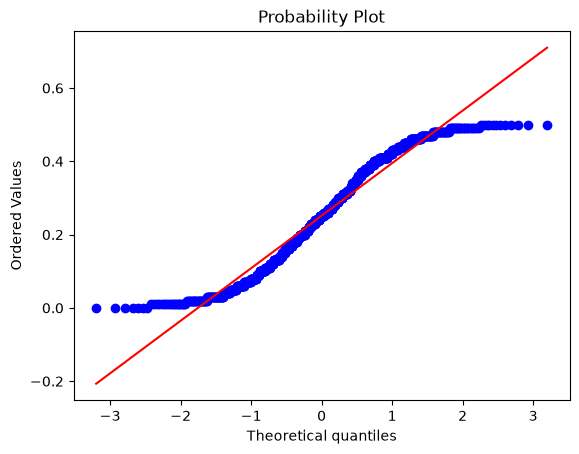

In [3]:
# Check if discounts are normally distributed
res = stats.probplot(df['Discount'], plot=plt)

In [21]:
# Additional test to see if discounts are not normally distributed

# Kolmogorov-Smirnov
res_discount = stats.kstest(df['Discount'], stats.norm.cdf)

print("Check p value for discount: ", res_discount.pvalue)




Check p value for discount:  1.064517291557782e-231


In [27]:
sales_mean = df['Sales'].mean()
sales_std = df['Sales'].std()

res_rating = stats.kstest(df['Sales'], stats.norm.cdf, args=(sales_mean, sales_std))

print(res_rating)

KstestResult(statistic=np.float64(0.0726264172529556), pvalue=np.float64(4.944805767374358e-05), statistic_location=np.float64(1517.0), statistic_sign=np.int8(-1))


### Discount data is not normally distributed. A KS Test was also conducted for additional test for normality - we got a p value less than 0.05 , proceeding with Spearman's test for correlation

In [4]:
# Test for correlation with Spearmen correlation

corr, p_val = stats.spearmanr(df['Discount'], df['Sales'])
print(f"Spearman Corr: {corr}, p-value: {p_val}")

Spearman Corr: 0.026632379372770375, p-value: 0.4001879216315177


### Compare groups, see if one item performs better than another


In [ ]:
# One way ANOVA

